In [1]:
#23.1
import folium

m=folium.Map(location=[10.760867, 106.667880],zoom_start=15)

folium.Marker([10.760867, 106.667880], popup="Trường đại học Kinh Tế TP.HCM cơ sở B",tooltip="UEH cs B", icon=folium.Icon(color='blue')).add_to(m)

dv = folium.FeatureGroup(name="Mua Sắm và Di Chuyển", show=False)
folium.Marker([10.759837, 106.664331], popup="Hãng xe khách",tooltip="Meko Limosine", icon=folium.Icon(color='green')).add_to(dv)
folium.Marker([10.770619, 106.669556], popup="Trung tâm thương mại",tooltip="Vạn Hạnh Mall", icon=folium.Icon(color='green')).add_to(dv)
dv.add_to(m)

hc = folium.FeatureGroup(name="Hành chính", show=False)
folium.Marker([10.761299, 106.674682], popup="Cơ quan hành chính",tooltip="UBND phường Vườn Lài", icon=folium.Icon(color='black')).add_to(hc)
hc.add_to(m)

bv = folium.FeatureGroup(name="bv", show=False)
folium.Marker([10.756522, 106.665882], popup="Y Tế",tooltip="Bệnh viện Truyền máu Huyết học", icon=folium.Icon(color='red')).add_to(bv)
folium.Marker([10.768859, 106.670415], popup="Y Tế",tooltip="Bệnh viện Nhi Đồng 1", icon=folium.Icon(color='red')).add_to(bv)
bv.add_to(m)

folium.LayerControl().add_to(m)

m

In [ ]:
#23.2
from geopy.distance import geodesic
import folium

# Giả lập 10 địa chỉ vớitọa độ 
dia_chi = [
    {"ten": "Điểm A", "vi_tri": [10.7590, 106.6700]},
    {"ten": "Điểm B", "vi_tri": [10.7590, 106.6700]},
    {"ten": "Điểm C", "vi_tri": [10.7700, 106.6650]},
    {"ten": "Điểm D", "vi_tri": [10.7720, 106.6980]},
    {"ten": "Điểm E", "vi_tri": [10.7715, 106.7040]},
    {"ten": "Điểm F", "vi_tri": [10.7620, 106.6500]},
    {"ten": "Điểm G", "vi_tri": [10.7769, 106.7009]},
    {"ten": "Điểm H", "vi_tri": [10.7650, 106.6800]},
    {"ten": "Điểm I", "vi_tri": [10.7940, 106.7210]},
    {"ten": "Điểm J", "vi_tri": [10.7799, 106.6990]}
]

center = [10.763212, 106.682348]

m = folium.Map(center, tiles="CartoDB positron", zoom_start=14)

folium.Marker(center, popup="Đại học Khoa học Tự nhiên", tooltip="Điểm trung tâm", icon=folium.Icon(color='red', icon='star')).add_to(m)

for dc in dia_chi:
    distance = geodesic(center, dc["vi_tri"]).km
    folium.PolyLine([dc["vi_tri"], center], tooltip=f"{distance:.2f} km", color="blue", opacity=0.7).add_to(m)   #dùng .2f để đỡ bị dài số thập phân
    folium.Marker(dc["vi_tri"], popup=f"Khoảng cách so với trung tâm: {distance:.2f} km", tooltip=dc['ten']).add_to(m)

m

In [ ]:
#23.3
import folium
from folium.plugins import HeatMap
import numpy as np
import pandas as pd
from geopy.geocoders import Nominatim

geolocator = Nominatim(user_agent="my_request") 
center = geolocator.geocode("Đại học Kinh tế TP.HCM, Hồ Chí Minh")
center_lat, center_lon = center.latitude, center.longitude

#tạo data giả định
lats = center_lat + np.random.normal(0, 0.005, 100)
lons = center_lon + np.random.normal(0, 0.005, 100)
df_orders = pd.DataFrame({'lat': lats, 'lon': lons})
heat_data = [[row['lat'], row['lon']] for index, row in df_orders.iterrows()]


m = folium.Map([center_lat, center_lon], tiles='CartoDB positron')

HeatMap(data=heat_data).add_to(m)
m

In [ ]:
#23.4
import folium
import geopandas as gpd
import pandas as pd
file_name = "vietnam.geojson" 
gdf_hcm = gpd.read_file(file_name)
data = {
    'name': ['Hồ Chí Minh city', 'Bình Dương', 'Đồng Nai', 'Bà Rịa - Vũng Tàu', 'Hà Nội', 'Đà Nẵng'],
    'doanh_thu': [956, 700, 800, 600, 580, 620]
}
df_data = pd.DataFrame(data)

merged = gdf_hcm.merge(df_data, on='name', how='left') #join left để không bị mất dữ liệu

m = folium.Map([16, 110], zoom_start=6, tiles='CartoDB positron')

folium.Choropleth(
    geo_data=merged,          
    data=merged,                
    columns=["name", "doanh_thu"], 
    key_on="feature.properties.name",
    legend_name="Doanh thu theo tỷ đồng",
    nan_fill_color="white",
    fill_color="YlOrRd"
).add_to(m)

m

In [ ]:
#23.5
import folium
from geopy.distance import geodesic
import random

random.seed(42)

TRUNG_TAM = [10.7627, 106.6827]
BAN_KINH = [3000, 5000, 10000]
MAU_SAC = ['green', 'orange', 'red']

m = folium.Map(location=TRUNG_TAM, zoom_start=12, tiles='CartoDB positron')

for r, mau in zip(BAN_KINH, MAU_SAC):
    folium.Circle(
        location=TRUNG_TAM,
        radius=r,
        color=mau,
        fill_color=mau,
        fill_opacity=0.1,
        weight=2,
        popup=f"Vung {r/1000:.0f} km"
    ).add_to(m)


KHACH_HANG = []
for _ in range(60):
    lat = TRUNG_TAM[0] + random.uniform(-0.09, 0.09)
    lon = TRUNG_TAM[1] + random.uniform(-0.09, 0.09)
    KHACH_HANG.append([lat, lon])

THONG_KE = {3: 0, 5: 0, 10: 0, "ngoai_vung": 0}

for kh in KHACH_HANG:
    kc = geodesic(TRUNG_TAM, kh).km
    
    if kc <= 3:
        THONG_KE[3] += 1
        mau_kh = 'green'
    elif kc <= 5:
        THONG_KE[5] += 1
        mau_kh = 'orange'
    elif kc <= 10:
        THONG_KE[10] += 1
        mau_kh = 'red'
    else:
        THONG_KE["ngoai_vung"] += 1
        mau_kh = 'gray'
        
    folium.CircleMarker(
        location=kh,
        radius=4,
        color=mau_kh,
        fill=True,
        fill_opacity=0.8,
        popup=f"Cach: {kc:.2f} km"
    ).add_to(m)

folium.Marker(
    TRUNG_TAM,
    popup="Trung tam phan phoi",
    icon=folium.Icon(color='black', icon='warehouse')
).add_to(m)

print("Phan tich vung phuc vu:")
print(f"  <= 3km: {THONG_KE[3]} khach")
print(f"  <= 5km: {THONG_KE[5]} khach")
print(f"  <= 10km: {THONG_KE[10]} khach")
print(f"  Ngoai vung: {THONG_KE['ngoai_vung']} khach")

m

Phan tich vung phuc vu:
  <= 3km: 1 khach
  <= 5km: 8 khach
  <= 10km: 40 khach
  Ngoai vung: 11 khach


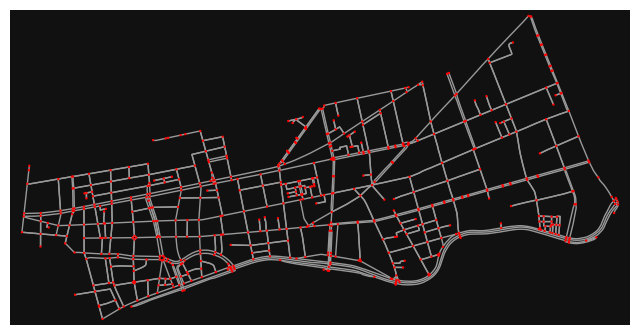

Số lượng nút giao: 586
Số lượng đoạn đường: 1311
Tổng chiều dài đường: 108.71 km
Chiều dài đường trung bình: 82.92 m
Mật độ nút giao: 137.24 nút/km²
Mật độ chiều dài đường: 25.46 km đường/km²


In [ ]:
#23.6
import osmnx as ox
import matplotlib.pyplot as plt

G = ox.graph_from_place("District 5, Ho Chi Minh city, Vietnam", network_type='drive')

G_projected = ox.project_graph(G)

fig, ax = ox.plot_graph(G_projected, node_size=3, node_color = 'red')
plt.show()
thong_so = ox.basic_stats(G_projected)

dien_tich_q5 = 4.27
mat_do_nut = thong_so['n'] / dien_tich_q5
mat_do_duong = (thong_so['edge_length_total'] / 1000) / dien_tich_q5


print(f"Số lượng nút giao: {thong_so['n']}")
print(f"Số lượng đoạn đường: {thong_so['m']}")
print(f"Tổng chiều dài đường: {thong_so['edge_length_total']/1000:.2f} km")
print(f"Chiều dài đường trung bình: {thong_so['edge_length_avg']:.2f} m")
print(f"Mật độ nút giao: {mat_do_nut:.2f} nút/km²")
print(f"Mật độ chiều dài đường: {mat_do_duong:.2f} km đường/km²")

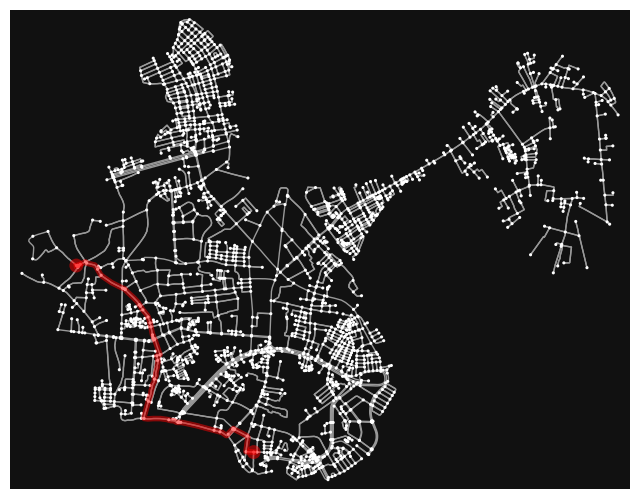

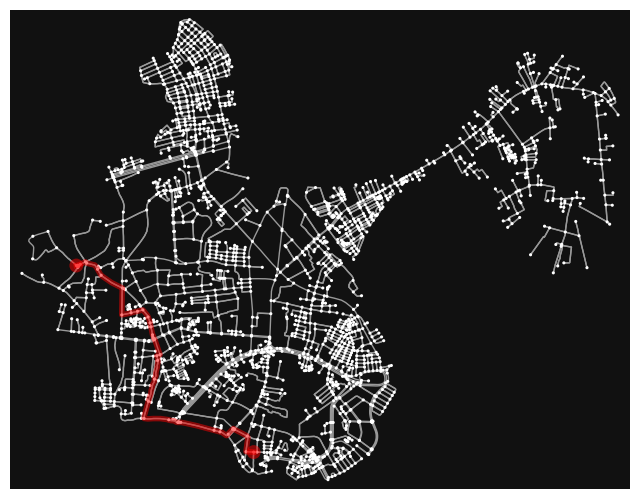

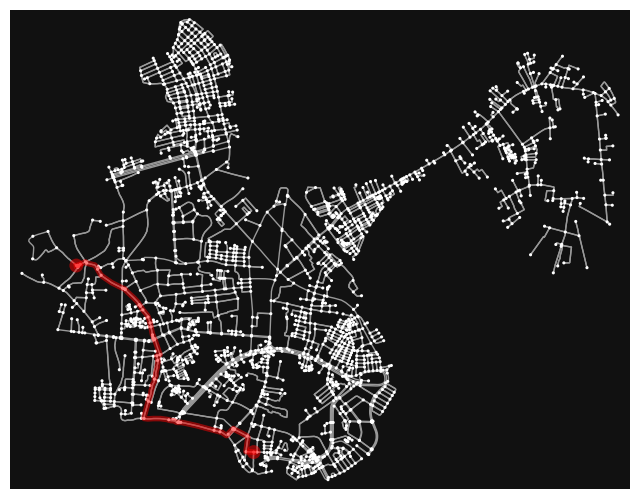

dijkstra: 0.005606s
A*: 0.003222s
bfs: 0.000977s


In [ ]:
23.7
import osmnx as ox
import networkx as nx
import time

G = ox.graph_from_place("Bình Thạnh District, Ho Chi Minh City, Vietnam", network_type='drive')
G_projected = ox.project_graph(G)

start_lat_lon = (10.789959, 106.709288) # Tiểu học Thạnh Mỹ Tây
end_lat_lon = (10.811097, 106.689667)   # Tina Cafe


orig_node = ox.distance.nearest_nodes(G, start_lat_lon[1], start_lat_lon[0])  #hàm này sử dụng toạ độ Oxy nên phải đảo kinh độ và vĩ độ
dest_node = ox.distance.nearest_nodes(G, end_lat_lon[1], end_lat_lon[0])


start_time = time.time()
dji_route = nx.shortest_path(G_projected, orig_node, dest_node, weight='length')
dijkstra_time = time.time() - start_time

start_time = time.time()
bfs_route = nx.shortest_path(G_projected, orig_node, dest_node)
bfs_time = time.time() - start_time

def heuristic(u, v):
    node_u = G_projected.nodes[u]
    node_v = G_projected.nodes[v]
    return ((node_u['x'] - node_v['x'])**2 + (node_u['y'] - node_v['y'])**2)**0.5


start_time = time.time()
a_star_route = nx.astar_path(G_projected, orig_node, dest_node, weight = 'length', heuristic = heuristic)
astar_time = time.time() - start_time

fig, ax = ox.plot_graph_route(G_projected, dji_route, node_size=5)
fig, ax = ox.plot_graph_route(G_projected, bfs_route, node_size=5)
fig, ax = ox.plot_graph_route(G_projected, a_star_route, node_size=5)

print(f"dijkstra: {dijkstra_time:.6f}s")
print(f"A*: {astar_time:.6f}s")
print(f"bfs: {bfs_time:.6f}s")


[ 4 17 18 32 37 40 41 43 44 48]
[2 5 3 9 0 7 4 6 1 8]


,khach_0,khach_1,khach_2,khach_3,khach_4,khach_5,khach_6,khach_7,khach_8,khach_9
xe_0,1638.101232,1696.248902,2577.282754,952.031093,3177.502925,3135.693485,726.822223,1917.310349,902.362010,187.406175
xe_1,1847.208887,2153.318044,3034.351897,1161.138748,3634.572068,3592.762627,851.541304,2126.418004,1359.431153,833.569559
xe_2,1821.209026,1807.416728,2050.574491,2058.921051,2650.794662,2608.985222,3551.418847,1285.547902,2155.191312,3005.967967
xe_3,2556.249771,811.410935,454.596416,2155.812493,1068.385821,1011.560232,3003.740281,2490.439394,1982.153105,2458.289401
xe_4,2693.002209,948.163373,61.935687,2292.564931,553.300632,496.475044,3140.492719,2645.679067,2118.905543,2595.041839
xe_5,1753.741184,2182.064943,3063.098795,1067.671046,3663.318966,3621.509526,979.023424,2032.950302,1281.423482,862.316457
xe_6,2182.839571,438.000735,503.407975,1782.402293,1103.628146,1061.818706,2630.330081,2135.516428,1608.742905,2084.879200
xe_7,1899.026611,189.323590,825.654201,1498.589333,1425.874372,1384.064931,2346.517121,1822.588026,1324.929945,1801.066240
xe_8,1190.568437,1802.174356,2683.208208,504.498299,3283.428379,3241.618938,1637.141229,1469.777554,724.660121,1168.506005
xe_9,2201.255361,534.456232,682.952999,1800.818083,1283.173170,1241.363730,2648.745871,2078.423850,1627.158695,2103.294991


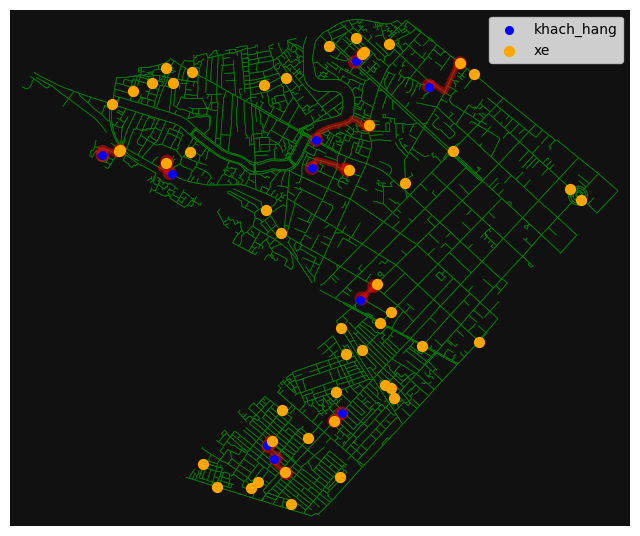

In [ ]:

#23.8
import osmnx as ox
import networkx as nx
import random
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point
from scipy.optimize import linear_sum_assignment

G = ox.graph_from_place("District 3, Ho Chi Minh City, Vietnam", network_type='walk')
G_projected = ox.project_graph(G)

nx.set_node_attributes(G_projected, 'intersection', 'node_type')


# tạo sample
def generate_entities_on_edges(graph, n, entity_type):
    entities = []
    edges = list(graph.edges(data=True))

    for i in range(n):
        u, v, data = random.choice(edges)


        nodes_data = graph.nodes
        t = random.random()
        point = Point(
            nodes_data[u]['x'] + (nodes_data[v]['x'] - nodes_data[u]['x']) * t,
            nodes_data[u]['y'] + (nodes_data[v]['y'] - nodes_data[u]['y']) * t
        )

        entities.append({
            "id": f"{entity_type}_{i}",
            "x": point.x,
            "y": point.y,
            "type": entity_type
        })

    return entities

khach_hang = generate_entities_on_edges(G_projected, n=10, entity_type='khach')
vehicles = generate_entities_on_edges(G_projected, n=50, entity_type='xe')

length_matrix = []

for v in vehicles:
    temp_row = []
    for c in khach_hang:
        try:
            c_node = ox.distance.nearest_nodes(G_projected, c["x"], c["y"])
            v_node = ox.distance.nearest_nodes(G_projected, v["x"], v["y"])

            dist = nx.shortest_path_length(
                G_projected,
                source=v_node,
                target=c_node,
                weight="length"
            )
            temp_row.append(dist)

        except nx.NetworkXNoPath:
            temp_row.append(float("inf"))

    length_matrix.append(temp_row)
row_i, column_i = linear_sum_assignment(length_matrix)
print(row_i)
print(column_i)
df_matrix = pd.DataFrame(
    length_matrix,
    index=[v["id"] for v in vehicles],
    columns=[c["id"] for c in khach_hang]
)
display(df_matrix)
    

fig, ax = ox.plot_graph(
    G_projected,
    node_size=0,
    edge_linewidth=0.5,
    edge_color="green",
    show=False,
    close=False
)

all_route = []

for i in range(len(row_i)):
    v = vehicles[row_i[i]]
    c = khach_hang[column_i[i]]

    v_node = ox.distance.nearest_nodes(G_projected, v["x"], v["y"])
    c_node = ox.distance.nearest_nodes(G_projected, c["x"], c["y"])

    route = ox.shortest_path(G_projected, v_node, c_node, weight="length")

    if route is not None:
        all_route.append(route)

fig, ax = ox.plot_graph_routes(
    G_projected,
    all_route,
    ax=ax,
    node_size=0,
    show=False,
    close=False
)

customer_x = [c["x"] for c in khach_hang]
customer_y = [c["y"] for c in khach_hang]
vehicle_x = [v["x"] for v in vehicles]
vehicle_y = [v["y"] for v in vehicles]

ax.scatter(customer_x, customer_y, c="blue", s=30, label="khach_hang", zorder=5)
ax.scatter(vehicle_x, vehicle_y, c="orange", s=50, label="xe", zorder=6)

ax.legend()
plt.show()

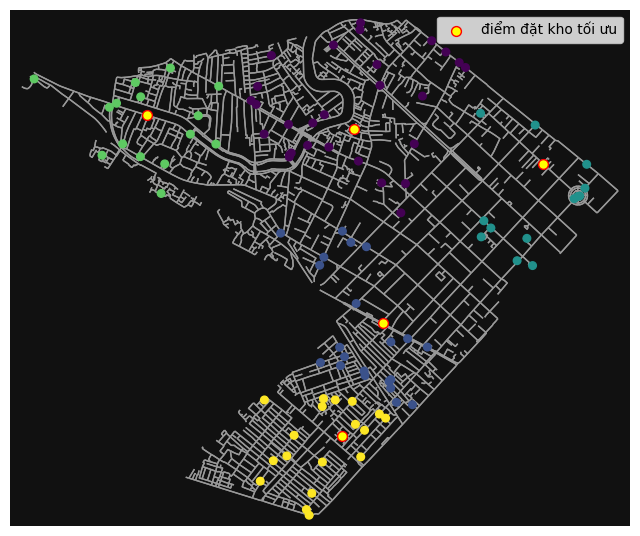

In [ ]:
#23.9
import osmnx as ox
import networkx as nx
import random
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
import numpy as np

G = ox.graph_from_place("District 3, Ho Chi Minh City, Vietnam", network_type='walk')
G_projected = ox.project_graph(G)

nx.set_node_attributes(G_projected, 'intersection', 'node_type')


#hàm này em sử dụng AI để có thể tạo được data sample
def generate_entities_on_edges(graph, n, entity_type):
    entities = []
    edges = list(graph.edges(data=True))

    for i in range(n):
        u, v, data = random.choice(edges)


        nodes_data = graph.nodes
        t = random.random()
        point = Point(
            nodes_data[u]['x'] + (nodes_data[v]['x'] - nodes_data[u]['x']) * t,
            nodes_data[u]['y'] + (nodes_data[v]['y'] - nodes_data[u]['y']) * t
        )

        entities.append({
            "id": f"{entity_type}_{i}",
            "x": point.x,
            "y": point.y,
            "type": entity_type
        })

    return entities

customers = generate_entities_on_edges(G_projected, n=100, entity_type='customer')


k = 5

customer_coords = np.array([[c["x"], c["y"]] for c in customers])

kmeans = KMeans(n_clusters=k)

labels = kmeans.fit_predict(customer_coords)
centroids = kmeans.cluster_centers_

for i, c in enumerate(customers):
    c["cluster"] = labels[i]

representative_points = []

for cluster_id in range(k):
    cluster_customers = [c for c in customers if c["cluster"] == cluster_id]
    centroid = centroids[cluster_id] 
    nearest_customer = min(cluster_customers,key=lambda c: np.linalg.norm(np.array([c["x"], c["y"]]) - centroid))
    representative_points.append(nearest_customer)

fig, ax = ox.plot_graph(
G_projected,
node_size=0,
show=False,
close=False
)


customer_x = [c["x"] for c in customers]
customer_y = [c["y"] for c in customers]

ax.scatter(
    customer_x,
    customer_y,
    c=labels,             
    s=30,
)
rep_x = [p["x"] for p in representative_points]
rep_y = [p["y"] for p in representative_points]

ax.scatter(
    rep_x,
    rep_y,
    c="yellow",
    edgecolors="red",
    s=50,
    label="điểm đặt kho tối ưu",
)

ax.legend()
plt.show()


In [ ]:
#23.10
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import folium
from folium.plugins import HeatMap
np.random.seed(42)
n_roads = 100
data = {
    'lat': np.random.uniform(10.75, 10.82, n_roads),
    'lon': np.random.uniform(106.63, 106.72, n_roads),
    'traffic_volume': np.random.randint(100, 1000, n_roads),
    'avg_speed': np.random.randint(5, 50, n_roads),
    'road_width': np.random.randint(1, 4, n_roads),
    'is_rush_hour': np.random.choice([0, 1], n_roads)
}
df = pd.DataFrame(data)
df['target_risk'] = (df['traffic_volume'] / 1000) * 0.4 + (1 - df['avg_speed'] / 50) * 0.4 + df['is_rush_hour'] * 0.2
X = df[['traffic_volume', 'avg_speed', 'road_width', 'is_rush_hour']]
y = df['target_risk']
model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X, y)
df['predicted_risk'] = model.predict(X)

m = folium.Map(location=[10.7769, 106.7009], zoom_start=13)

heat_data = [[row['lat'], row['lon'], row['predicted_risk']] for index, row in df.iterrows()]
HeatMap(heat_data, radius=25, blur=15, min_opacity=0.5).add_to(m)

safe_points = df[df['predicted_risk'] < 0.3].head(5)
route_coords = [[row['lat'], row['lon']] for index, row in safe_points.iterrows()]
if len(route_coords) > 1:
    folium.PolyLine(route_coords, color="green", weight=5, opacity=0.8,tooltip="Tuyến đường thay thế gợi ý (Rủi ro thấp)").add_to(m)

for index, row in df[df['predicted_risk'] > 0.7].head(10).iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6, color='red', fill=True,
        popup=f"Nguy cơ cao: {row['predicted_risk']:.2f}"
    ).add_to(m)
m

In [ ]:
#23.11
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import folium


np.random.seed(42)

dates = pd.date_range(start='2024-01-01', periods=30*24, freq='h') # Sửa 'H' thành 'h'
areas = {'Q1': [10.7769, 106.7009], 'Q3': [10.7750, 106.6850], 'BT': [10.8000, 106.7100]}

data = []
for d in dates:
    for name, coord in areas.items():
       
        demand = 10 * d.hour + 50 * list(areas.keys()).index(name) + np.random.randint(0, 50)
        data.append([d.hour, list(areas.keys()).index(name), coord[0], coord[1], demand, name])

df = pd.DataFrame(data, columns=['hour', 'area_id', 'lat', 'lon', 'demand', 'area'])


X = df[['hour', 'area_id']]
y = df['demand']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

print(f"✅ Độ chính xác mô hình (R2): {model.score(X_test, y_test):.2f}")


df_pred = df.copy()
df_pred['predicted'] = model.predict(X)

 
m = folium.Map(location=[10.77, 106.70], zoom_start=12)


data_12h = df_pred[df_pred['hour'] == 12]

for _, row in data_12h.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=row['predicted'] / 5, 
        color='red',
        fill=True,
        popup=f"{row['area']}: {row['predicted']:.0f} đơn"
    ).add_to(m)

m

✅ Độ chính xác mô hình (R2): 0.96


In [3]:
import folium
from folium.plugins import Fullscreen, MeasureControl


m = folium.Map(location=[10.76, 106.68], zoom_start=11, tiles='CartoDB positron')


layer_vung = folium.FeatureGroup(name='🗺️ Vùng phân phối', show=True)


folium.Polygon(
    locations=[[10.810, 106.680], [10.815, 106.710], [10.795, 106.720], [10.775, 106.710], [10.770, 106.690]],
    color='#2563eb', weight=2, fill_color='#2563eb', fill_opacity=0.12,
    popup='<b>📦 Vùng Bắc</b><br>Doanh thu: 4.2 tỷ/tháng<br>Đơn hàng: 12.500/ngày<br>Hiệu suất giao: 94%'
).add_to(layer_vung)


folium.Polygon(
    locations=[[10.770, 106.690], [10.775, 106.710], [10.760, 106.705], [10.745, 106.695], [10.750, 106.675]],
    color='#16a34a', weight=2, fill_color='#16a34a', fill_opacity=0.12,
    popup='<b>📦 Vùng Trung tâm</b><br>Doanh thu: 6.8 tỷ/tháng<br>Đơn hàng: 21.000/ngày<br>Hiệu suất giao: 98%'
).add_to(layer_vung)


folium.Polygon(
    locations=[[10.745, 106.695], [10.760, 106.705], [10.730, 106.700], [10.710, 106.690], [10.720, 106.670]],
    color='#ea580c', weight=2, fill_color='#ea580c', fill_opacity=0.12,
    popup='<b>📦 Vùng Nam</b><br>Doanh thu: 2.5 tỷ/tháng<br>Đơn hàng: 7.800/ngày<br>Hiệu suất giao: 87%'
).add_to(layer_vung)

layer_vung.add_to(m)


layer_diem = folium.FeatureGroup(name='📍 Hạ tầng Logistics', show=True)


folium.Marker([10.725, 106.685], 
              popup='<b>🏭 Kho trung tâm</b><br>Công suất: 5000 đơn/giờ<br>Trạng thái: Hoạt động 24/7',
              icon=folium.Icon(color='red', icon='warehouse')).add_to(layer_diem)


folium.Marker([10.795, 106.700], popup='<b> Hub Bắc</b><br>Xe đang hoạt động: 18/20', icon=folium.Icon(color='blue')).add_to(layer_diem)
folium.Marker([10.760, 106.695], popup='<b>🟢 Hub Trung tâm</b><br>Xe đang hoạt động: 32/35', icon=folium.Icon(color='green')).add_to(layer_diem)
folium.Marker([10.730, 106.690], popup='<b>🟠 Hub Nam</b><br>Xe đang hoạt động: 11/15', icon=folium.Icon(color='orange')).add_to(layer_diem)

layer_diem.add_to(m)


layer_tuyen = folium.FeatureGroup(name='🛣️ Tuyến vận chuyển', show=False)


folium.PolyLine([[10.725, 106.685], [10.760, 106.695]], color='#7c3aed', weight=4, opacity=0.8, popup='🛣️ Tuyến trục: Kho → Hub Trung tâm').add_to(layer_tuyen)
folium.PolyLine([[10.760, 106.695], [10.795, 106.700]], color='#7c3aed', weight=4, opacity=0.8, popup='🛣️ Tuyến nhánh: Hub TT → Hub Bắc').add_to(layer_tuyen)
folium.PolyLine([[10.760, 106.695], [10.730, 106.690]], color='#7c3aed', weight=4, opacity=0.8, popup='🛣️ Tuyến nhánh: Hub TT → Hub Nam').add_to(layer_tuyen)


folium.PolyLine([[10.795, 106.700], [10.805, 106.710], [10.790, 106.715], [10.780, 106.705], [10.795, 106.700]], 
                color='#6b7280', weight=2, dash_array='6, 4', popup='🔄 Vòng giao hàng Vùng Bắc').add_to(layer_tuyen)
folium.PolyLine([[10.760, 106.695], [10.770, 106.700], [10.765, 106.685], [10.750, 106.690], [10.760, 106.695]], 
                color='#6b7280', weight=2, dash_array='6, 4', popup='🔄 Vòng giao hàng Vùng Trung tâm').add_to(layer_tuyen)

layer_tuyen.add_to(m)


folium.LayerControl(collapsed=False, position='topright').add_to(m)
Fullscreen(position='topright').add_to(m)
MeasureControl(position='topleft').add_to(m)

dashboard_html = '''
<div style="position: fixed; bottom: 30px; left: 30px; z-index:1000; background: #ffffff; padding: 16px; border-radius: 8px; box-shadow: 0 4px 12px rgba(0,0,0,0.15); width: 280px; font-family: Arial, sans-serif;">
    <h4 style="margin: 0 0 12px 0; color: #111827; font-size: 16px;">📊 Dashboard Logistics TP.HCM</h4>
    <div style="margin-bottom: 8px; padding: 8px; background: #eff6ff; border-radius: 4px;">
        <b style="color: #2563eb;">🔵 Vùng Bắc</b><br>
        <span style="font-size: 13px; color: #4b5563;">Doanh thu: 4.2 tỷ | Đơn: 12.5k/ngày</span>
    </div>
    <div style="margin-bottom: 8px; padding: 8px; background: #f0fdf4; border-radius: 4px;">
        <b style="color: #16a34a;">🟢 Vùng Trung tâm</b><br>
        <span style="font-size: 13px; color: #4b5563;">Doanh thu: 6.8 tỷ | Đơn: 21k/ngày</span>
    </div>
    <div style="margin-bottom: 8px; padding: 8px; background: #fff7ed; border-radius: 4px;">
        <b style="color: #ea580c;">🟠 Vùng Nam</b><br>
        <span style="font-size: 13px; color: #4b5563;">Doanh thu: 2.5 tỷ | Đơn: 7.8k/ngày</span>
    </div>
    <hr style="margin: 10px 0; border: none; border-top: 1px solid #e5e7eb;">
    <p style="margin: 0; font-size: 12px; color: #6b7280;">
        ✅ Bật/tắt layer để phân tích kịch bản<br>
        📏 Dùng thước đo (góc trái) để tính cự ly<br>
        🖱️ Click vào đối tượng để xem chi tiết KPI
    </p>
</div>
'''
m.get_root().html.add_child(folium.Element(dashboard_html))

m